# Section 6 Using Pretrained Models from Keras

## 1 Load Pretrained Models

In [33]:
import tensorflow as tf

model = tf.keras.applications.resnet50.ResNet50(weights="imagenet")
model.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

## 2 Crop and Resize Images

### 2.1 A Test with Dummy Data

********************************************
Data type:  uint8
Data shape:  (427, 640, 3)
Data value range:  0 255


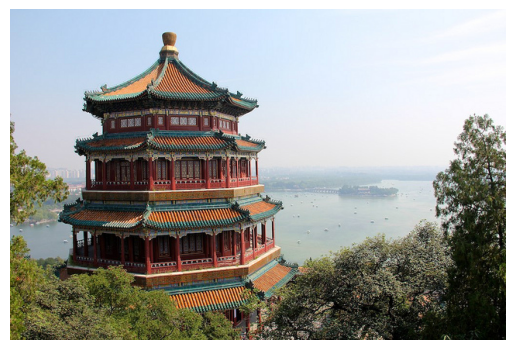

********************************************
Data type:  uint8
Data shape:  (427, 640, 3)
Data value range:  0 255


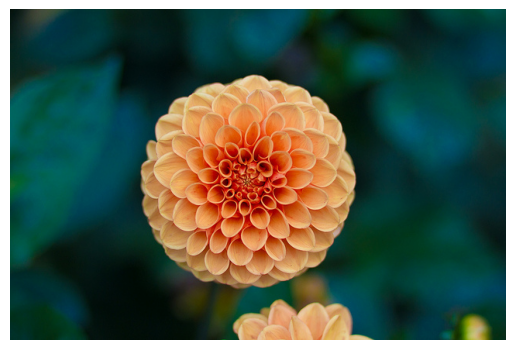

In [34]:
# Plot dummy images
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_sample_image
from typing import List, Optional, Sequence


def plot_images(images: Sequence[np.ndarray], titles: Optional[Sequence[str]] = None) -> None:
    def plot_image(image: np.ndarray, title: Optional[str] = None):
        fig, ax = plt.subplots()
        ax.imshow(image.astype(np.uint8))
        ax.axis("off")
        if title:
            ax.set_title(title)
        plt.show()

    if titles is None:
        titles = [None] * len(images)

    for image, title in zip(images, titles):
        print("********************************************")
        print("Data type: ", image.dtype)
        print("Data shape: ", image.shape)
        print("Data value range: ", np.min(images), np.max(images))
        plot_image(image, title)


image_names = ["china.jpg", "flower.jpg"]
images = np.array([load_sample_image(name) for name in image_names])
images_in = images / 255
plot_images(images)

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


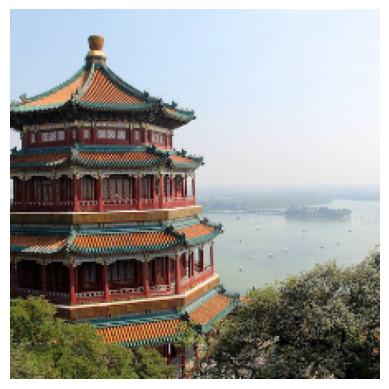

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


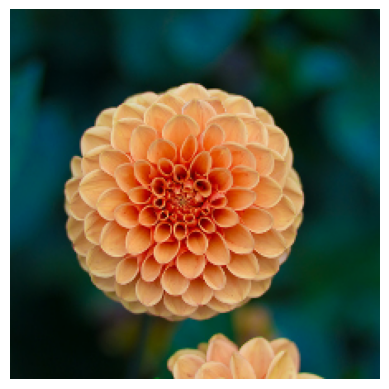

In [35]:
# Crop and resize dummy images
def crop_resize_images(images: Sequence[Sequence[Sequence[Sequence[float]]]]) -> List[tf.Tensor]:
    # Crops
    heights, widths, channels = np.array(list(zip(*[img.shape for img in images])))
    crops = 0.5 * (1 - heights / widths)

    # Boxes
    boxes = [[0, crop, 1, (1 - crop)] for crop in crops]

    # Crop and resize
    return [tf.image.crop_and_resize([image], boxes=[box], box_indices=[0], crop_size=[224, 224]).numpy().astype(np.uint8)[0] for i_image, (image, box) in enumerate(zip(images, boxes))]
    # return tf.image.crop_and_resize(images, boxes=boxes, box_indices=range(len(images)), crop_size=[224, 224]).numpy().astype(np.uint8)


plot_images(crop_resize_images(images))

### 2.2 Crop and Resize the Target Images
This is not required if using `tf.keras.utils.image_dataset_from_directory`, which provides the functions of cropping and resizing.

In [36]:
def load_images(paths_images) -> List[np.ndarray]:
    return [tf.keras.utils.img_to_array(tf.keras.utils.load_img(path_img)) for path_img in paths_images]

In [37]:
from pathlib import Path

dir_data = Path("data")
dir_data_raw = dir_data / "raw"
paths_images_raw = list(dir_data_raw.rglob("*.jpeg"))
paths_images_raw

[PosixPath('data/raw/n02099712/n02099712_1028.jpeg'),
 PosixPath('data/raw/n01440764/n01440764_10026.jpeg'),
 PosixPath('data/raw/n03843555/n03843555_10375.jpeg'),
 PosixPath('data/raw/n04141975/n04141975_10078.jpeg'),
 PosixPath('data/raw/n03670208/n03670208_1059.jpeg'),
 PosixPath('data/raw/n04356056/n04356056_10101.jpeg')]

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


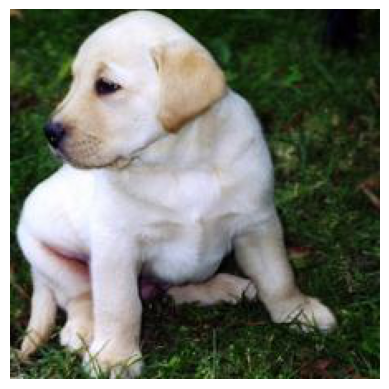

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


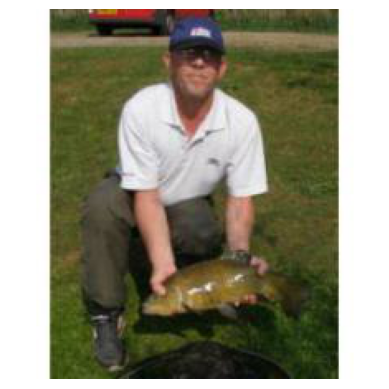

In [38]:
dir_data_prep = dir_data / "preprocessed"
paths_images_prep = [dir_data_prep / path_img_raw.name for path_img_raw in paths_images_raw]
images_prep = crop_resize_images(load_images(paths_images_raw))

for path_img_prep, img_prep in zip(paths_images_prep, images_prep):
    tf.keras.utils.save_img(path=path_img_prep, x=img_prep)

images_prep_reload = load_images(paths_images_prep)
plot_images(images_prep_reload[:2])

## 3 Load Data

In [39]:
# Rename "*.JPEG" -> ".jpeg"
from pathlib import Path

for path in dir_data.rglob("*.JPEG"):
    path.rename(path.with_suffix(".jpeg"))

paths_files = list(dir_data.rglob("*.*"))
paths_files

[PosixPath('data/LOC_synset_mapping.txt'),
 PosixPath('data/raw/n02099712/n02099712_1028.jpeg'),
 PosixPath('data/raw/n01440764/n01440764_10026.jpeg'),
 PosixPath('data/raw/n03843555/n03843555_10375.jpeg'),
 PosixPath('data/raw/n04141975/n04141975_10078.jpeg'),
 PosixPath('data/raw/n03670208/n03670208_1059.jpeg'),
 PosixPath('data/raw/n04356056/n04356056_10101.jpeg'),
 PosixPath('data/preprocessed/n04356056_10101.jpeg'),
 PosixPath('data/preprocessed/n01440764_10026.jpeg'),
 PosixPath('data/preprocessed/n04141975_10078.jpeg'),
 PosixPath('data/preprocessed/n03843555_10375.jpeg'),
 PosixPath('data/preprocessed/n02099712_1028.jpeg'),
 PosixPath('data/preprocessed/n03670208_1059.jpeg')]

In [40]:
path_classes = dir_data / "LOC_synset_mapping.txt"
with open(path_classes, "r") as fp:
    class_names = np.array(fp.readlines())

print(class_names[:5])

['n01440764 tench, Tinca tinca\n'
 'n01443537 goldfish, Carassius auratus\n'
 'n01484850 great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias\n'
 'n01491361 tiger shark, Galeocerdo cuvieri\n'
 'n01494475 hammerhead, hammerhead shark\n']


### 3.1 Load data with `tf.keras.utils.image_dataset_from_directory`

In [41]:
dir_data_raw.absolute()

PosixPath('/home/yu/Projects/data-science/homl/ch14_deep_computer_vision_using_convolutional_neural_networks/data/raw')

In [42]:
batch_size = 32
img_height = 224
img_width = 224

ds = tf.keras.utils.image_dataset_from_directory(
    directory=dir_data_raw.absolute(),
    # class_names=class_names,
    batch_size=batch_size,
    image_size=(224, 224),
    shuffle=False,
    crop_to_aspect_ratio=True,
)
ds

Found 6 files belonging to 6 classes.


<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


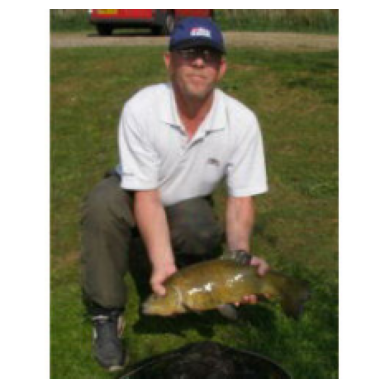

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


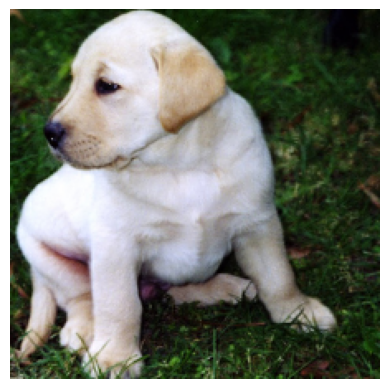

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


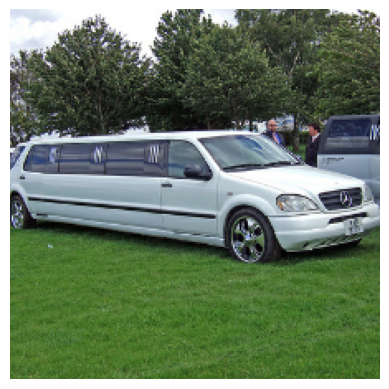

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


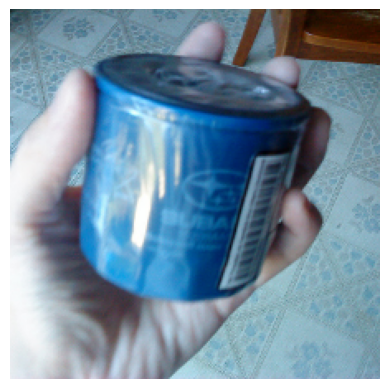

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


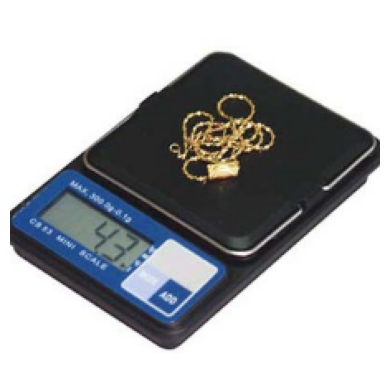

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


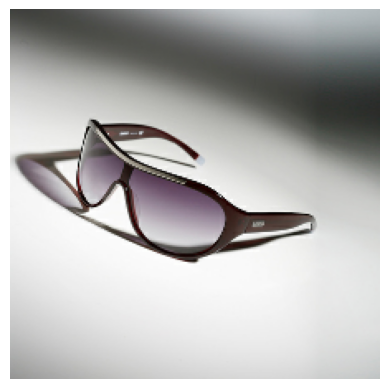

In [43]:
for images, labels in ds:
    images = [img.numpy().astype(np.uint8) for img in images]
    plot_images(images)

### 3.2 Load data with `tf.keras.utils.load_img`

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


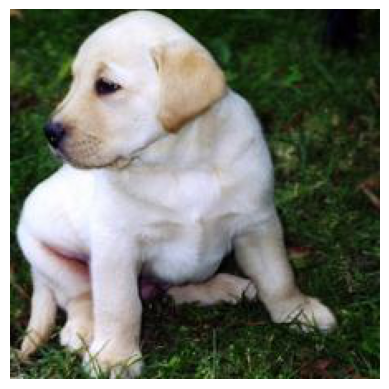

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


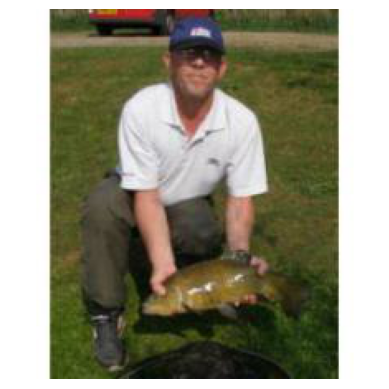

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


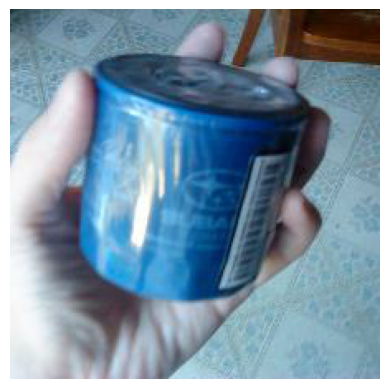

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


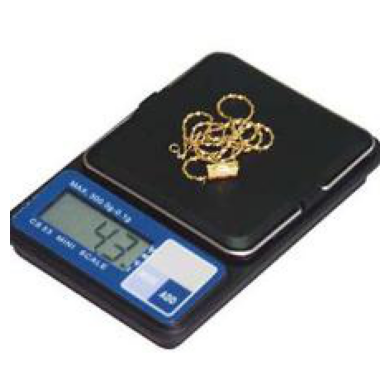

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


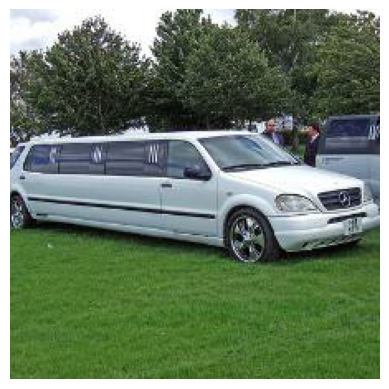

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


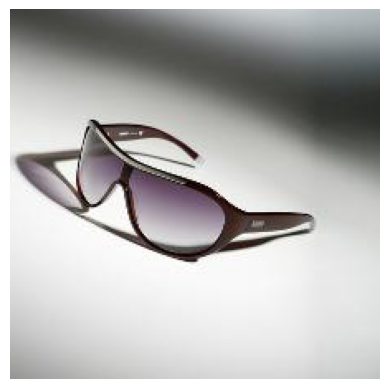

In [44]:
images = [tf.keras.utils.img_to_array(tf.keras.utils.load_img(path_img_prep)) for path_img_prep in paths_images_prep]
plot_images(images)

## 4 Inferencing

### 4.1 With TF Dataset Loaded with `tf.keras.utils.image_dataset_from_directory`

In [45]:
y_prob = model.predict(ds)
y_prob.shape

1/1 [==============================] - 1s 841ms/step


(6, 1000)

In [46]:
y_pred = np.argmax(y_prob, axis=1)
print(y_pred)

[  0 208 627 862 778 836]


In [47]:
print(class_names[y_pred])

['n01440764 tench, Tinca tinca\n' 'n02099712 Labrador retriever\n'
 'n03670208 limousine, limo\n' 'n04456115 torch\n'
 'n04141975 scale, weighing machine\n' 'n04355933 sunglass\n']


********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


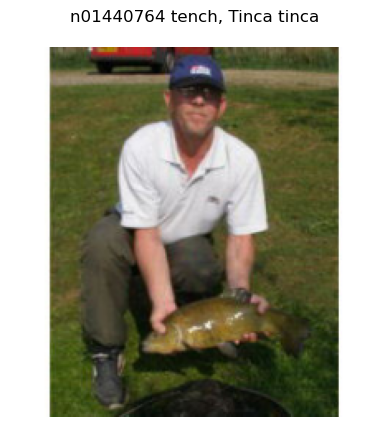

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


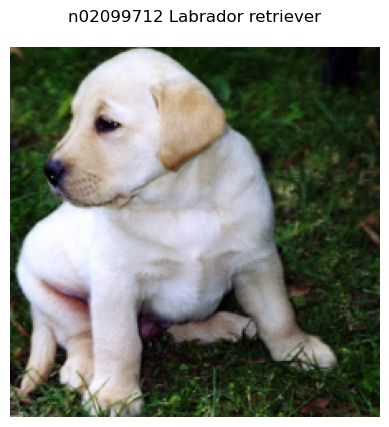

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


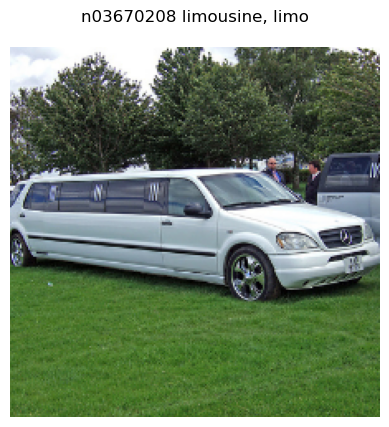

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


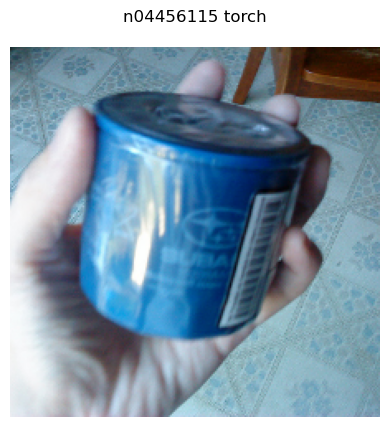

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


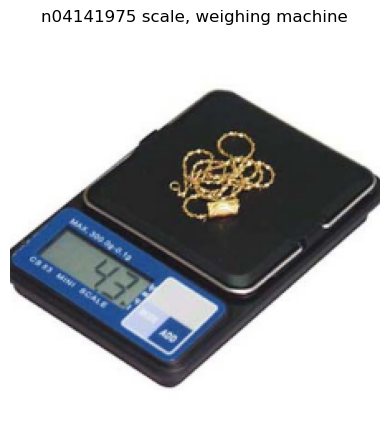

********************************************
Data type:  uint8
Data shape:  (224, 224, 3)
Data value range:  0 255


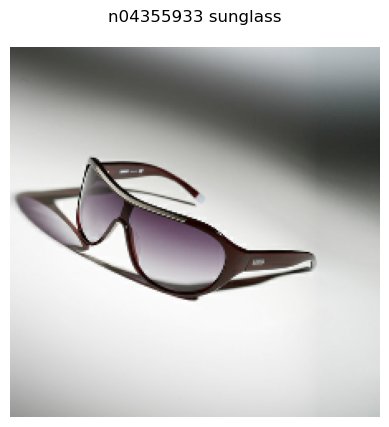

In [48]:
# Plot images with predicted labels together
images_ds, labels = list(ds)[0]
images_ds = [img.numpy().astype(np.uint8) for img in images_ds]

plot_images(images_ds, class_names[y_pred])

### 4.2 With Images Loaded with `tf.keras.utils.load_img`

In [49]:
images[1].shape

(224, 224, 3)

In [50]:
y_prob = model.predict(np.array(images))
y_prob.shape

1/1 [==============================] - 1s 827ms/step


(6, 1000)

In [51]:
y_pred = np.argmax(y_prob, axis=1)
print(y_pred)

[208   0 862 778 627 836]


In [52]:
print(class_names[y_pred])

['n02099712 Labrador retriever\n' 'n01440764 tench, Tinca tinca\n'
 'n04456115 torch\n' 'n04141975 scale, weighing machine\n'
 'n03670208 limousine, limo\n' 'n04355933 sunglass\n']


********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


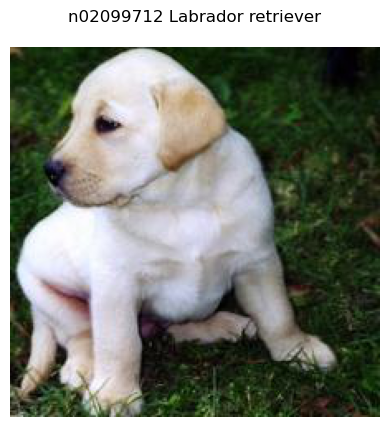

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


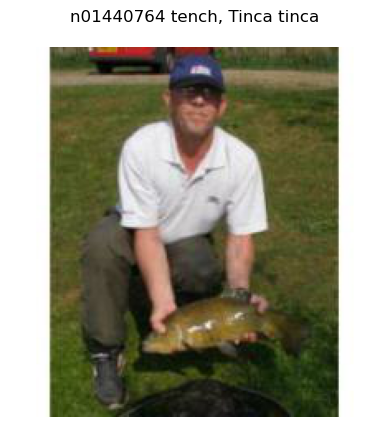

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


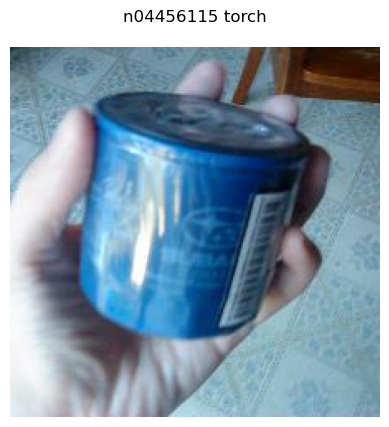

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


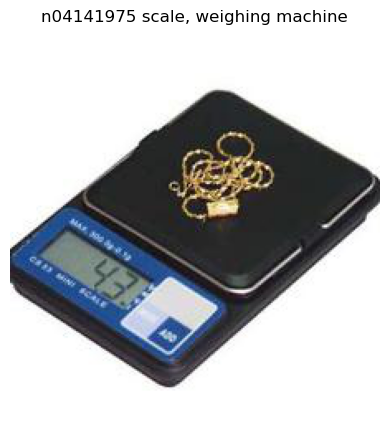

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


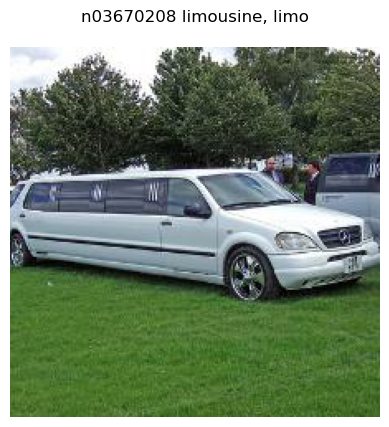

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  0.0 255.0


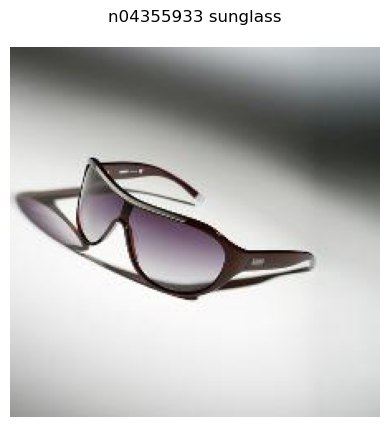

In [53]:
plot_images(images, class_names[y_pred])

### 4.3 With `tf.keras.applications.resnet50.preprocess_input`

In [54]:
images_prep = tf.keras.applications.resnet50.preprocess_input(np.array(images))
y_prob = model.predict(images_prep)
y_prob.shape

1/1 [==============================] - 0s 27ms/step


(6, 1000)

In [55]:
y_pred = np.argmax(y_prob, axis=1)
print(y_pred)

[208   0 686 778 627 836]


In [56]:
print(class_names[y_pred])

['n02099712 Labrador retriever\n' 'n01440764 tench, Tinca tinca\n'
 'n03843555 oil filter\n' 'n04141975 scale, weighing machine\n'
 'n03670208 limousine, limo\n' 'n04355933 sunglass\n']


********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  -123.68 151.061


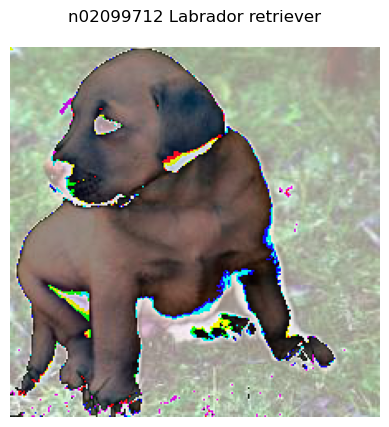

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  -123.68 151.061


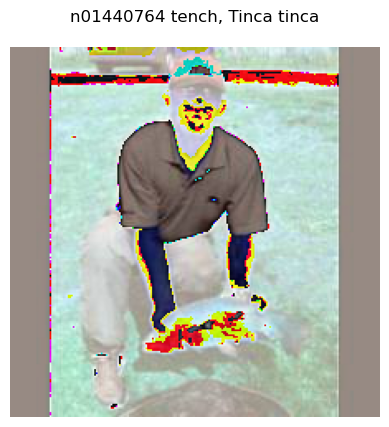

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  -123.68 151.061


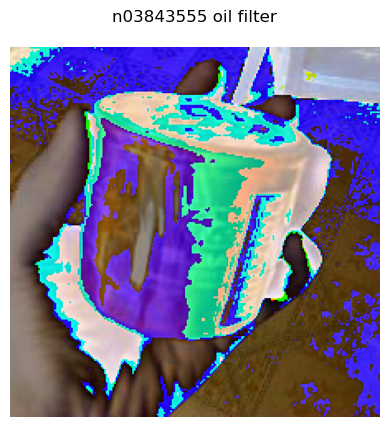

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  -123.68 151.061


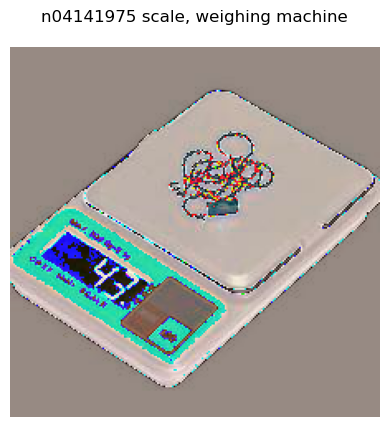

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  -123.68 151.061


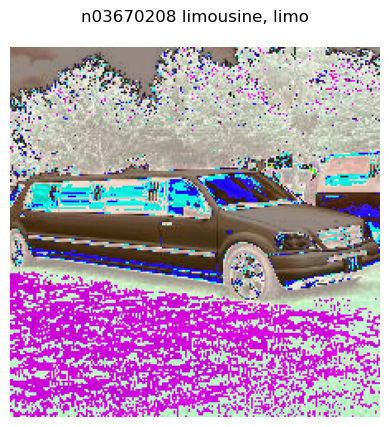

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  -123.68 151.061


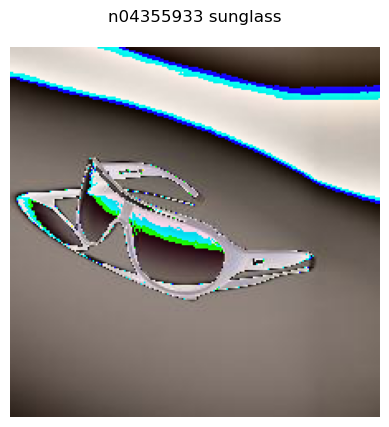

In [57]:
plot_images(images_prep, class_names[y_pred])

## 5 Top-K Classes

Image 0


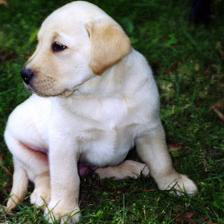

  n02099712 - Labrador_retriever  : 98.75%
  n02099601 - golden_retriever    : 1.17%
  n02088364 - beagle              : 0.03%
*******************************
Image 1


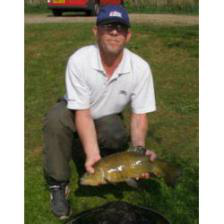

  n01440764 - tench               : 91.32%
  n02395406 - hog                 : 1.46%
  n02396427 - wild_boar           : 1.35%
*******************************
Image 2


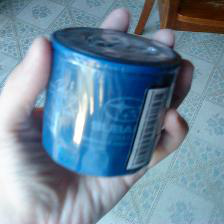

  n03843555 - oil_filter          : 93.93%
  n04557648 - water_bottle        : 0.86%
  n04067472 - reel                : 0.52%
*******************************
Image 3


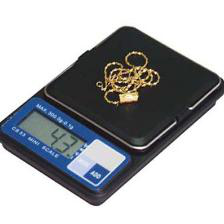

  n04141975 - scale               : 94.16%
  n02840245 - binder              : 1.75%
  n04041544 - radio               : 0.81%
*******************************
Image 4


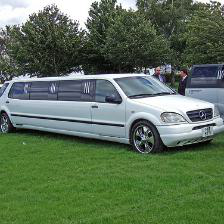

  n03670208 - limousine           : 99.98%
  n02814533 - beach_wagon         : 0.01%
  n04065272 - recreational_vehicle: 0.00%
*******************************
Image 5


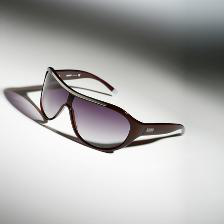

  n04355933 - sunglass            : 69.00%
  n04356056 - sunglasses          : 31.00%
  n04133789 - sandal              : 0.00%
*******************************


In [58]:
from PIL import Image

top_k_classes = tf.keras.applications.resnet50.decode_predictions(y_prob, top=3)
for id_image, image in enumerate(images):
    print(f"Image {id_image}")
    display(Image.fromarray(image.astype(np.uint8)))
    for id_class, name_class, y_prob_class in top_k_classes[id_image]:
        print(f"  {id_class} - {name_class:20s}: {y_prob_class*100:.2f}%")
    print("*******************************")